In [3]:
import scipy.sparse as sp
import numpy as np

real_graph = sp.load_npz('testing graphs/mobility_graph_csr.npz')
synthetic_graph = sp.load_npz('testing graphs/synthetic_graph.npz')
synthetic_graph2 = sp.load_npz('testing graphs/synthetic_graph_2.npz')

synthetic_graphfixedmaybe = sp.load_npz('synthetic_graph_fixed?.npz')
synthetic_graphfixedpls = sp.load_npz('testing graphs/synthetic_graph_fixedpls.npz')

synthetic_graphfixedidk = sp.load_npz('testing graphs/synthetic_graph_g0.55,d0.0028.npz')

synthetic_graphhopesandprayers = sp.load_npz('testing graphs/please.npz')


synthetic_graphhopesandprayers = sp.load_npz('testing graphs/whatever.npz')


radiation_graph = sp.load_npz('testing graphs/synthetic_FUllradiation.npz')
radiation_graph2 = sp.load_npz('testing graphs/synthetic_radiationK.npz')

test = sp.load_npz('testing graphs/testing.npz')

testing = sp.load_npz('testing graphs/radiation_newtest.npz')


data = np.load('testing graphs/mobility_metadata_real.npz')
population_real = data['population']

data = np.load('testing graphs/mobility_metadata_newtest.npz')
population_test = data['population']

FileNotFoundError: [Errno 2] No such file or directory: 'synthetic_graph_fixed?.npz'

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

def visualise_graph(graph):
    graph = nx.from_scipy_sparse_array(graph)

    # threshold = 0.5  # Example threshold
    # elarge = [(u, v) for (u, v, d) in graph.edges(data=True) if d["weight"] > threshold]

    # 3. Draw
    pos = nx.spring_layout(graph, seed=42)  # Positions for all nodes
    nx.draw_networkx_nodes(graph, pos, node_size=10)
    nx.draw_networkx_edges(graph, pos, width=0.1, alpha=0.5)

    plt.title("Flow Graph")
    plt.show()

In [7]:
import networkx as nx
import scipy.sparse as sp

def new_visual(matrix, title):
    # 1. Convert the CSR matrix to a NetworkX Graph
    # Use create_using=nx.DiGraph() if your mobility flows are directional (i -> j)
    G = nx.from_scipy_sparse_array(matrix, create_using=nx.DiGraph())

    # 2. Calculate node weights for sizing
    # Summing columns (axis=0) gives total incoming flow per node
    node_weights = np.array(matrix.sum(axis=0)).flatten()
    sizes = 5 + (node_weights / (node_weights.max() + 1e-6)) * 300

    # 3. Calculate the Layout using the Graph Object G, not the matrix
    print("Calculating layout...")
    pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)

    # 4. Filter for strong edges ONLY (for plotting clarity)
    edge_threshold = np.percentile(matrix.data, 98)

    plt.figure(figsize=(14, 10))

    # Draw Nodes
    nodes = nx.draw_networkx_nodes(G, pos,
                                   node_size=sizes,
                                   node_color=node_weights,
                                   cmap=plt.cm.plasma,
                                   alpha=0.8)

    # Draw Edges (Top 2% only)
    rows, cols = matrix.nonzero()
    weights = matrix.data
    for r, c, w in zip(rows, cols, weights):
        if w > edge_threshold:
            plt.annotate("", xy=pos[c], xytext=pos[r],
                         arrowprops=dict(arrowstyle="-", color='gray', alpha=0.1, lw=0.5))

    plt.title(f"Mobility Network Structure {title}")
    plt.axis('off')
    plt.show()

Calculating layout...


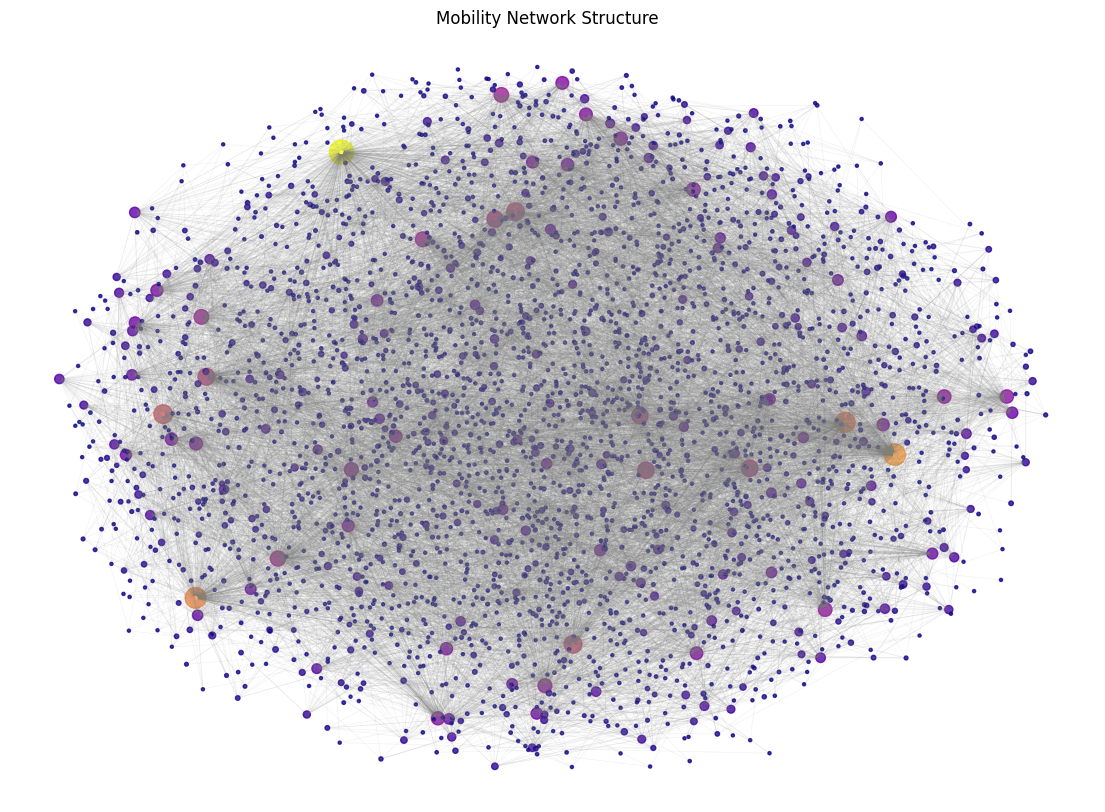

In [103]:
new_visual(synthetic_graphhopesandprayers, ' ')

Calculating layout...


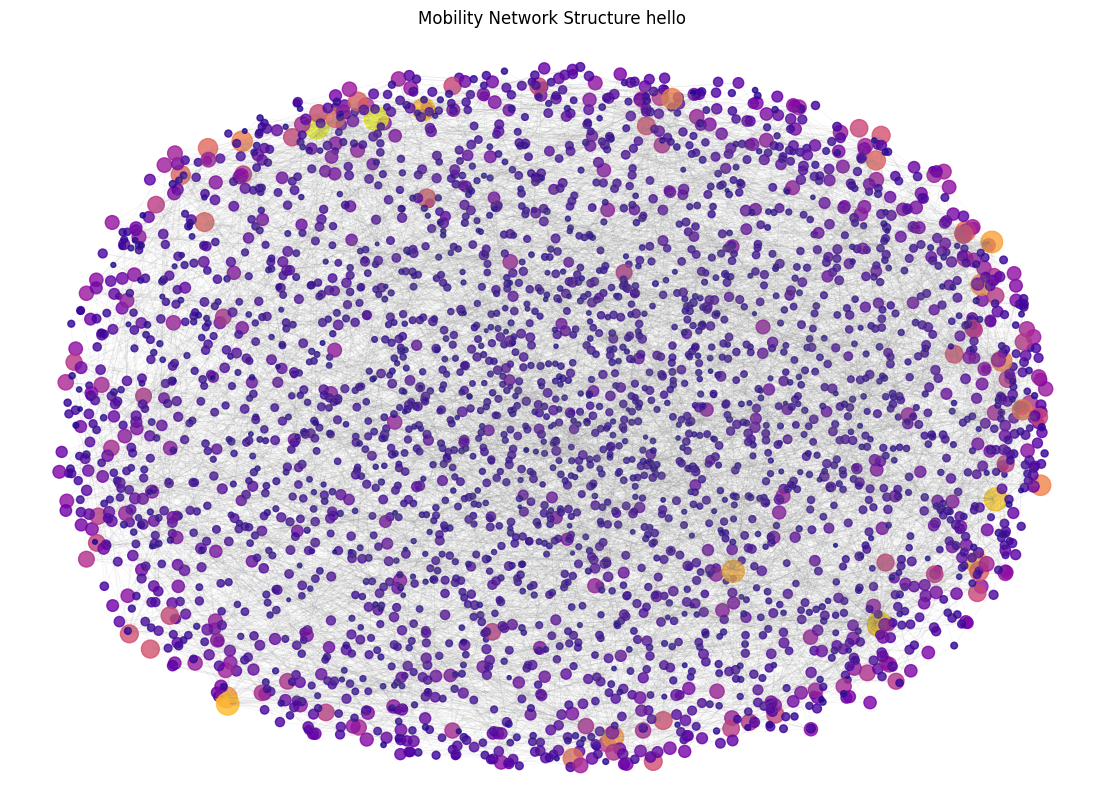

In [45]:
new_visual(real_graph, 'hello')

Calculating layout...


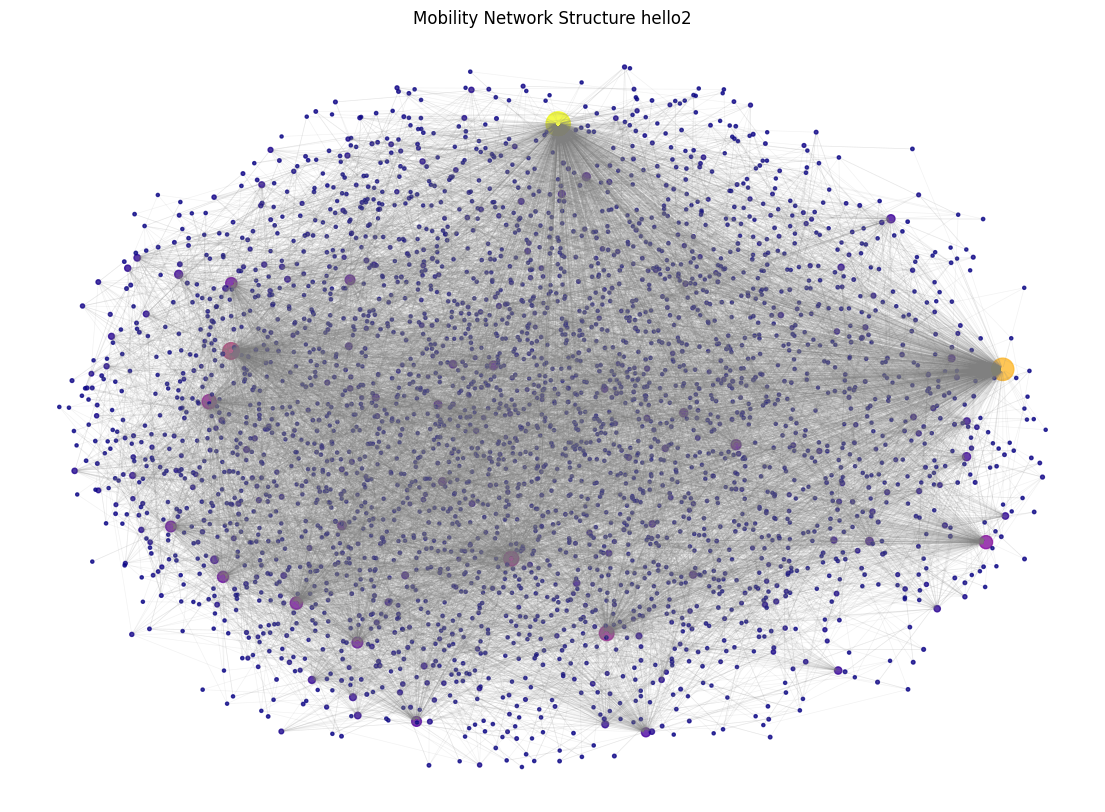

In [46]:
new_visual(synthetic_graph, 'hello2')

In [ ]:
new_visual(synthetic_graph2, 'hello2')

In [81]:
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel

def compute_mmd(x, y, gamma=1.0):



    x = x.reshape(-1, 1)

    y = y.reshape(-1, 1)



    k_xx = rbf_kernel(x, x, gamma=gamma).mean()
    k_yy = rbf_kernel(y, y, gamma=gamma).mean()

    k_xy = rbf_kernel(x, y, gamma=gamma).mean()


    return k_xx + k_yy - 2 * k_xy


gen_degrees = np.array(testing.sum(axis=1)).flatten()
real_degrees = np.array(real_graph.sum(axis=1)).flatten()

gen_log = np.log1p(gen_degrees)
real_log = np.log1p(real_degrees)



from scipy.spatial.distance import pdist

# Combine a sample of both to find a good scale
combined = np.concatenate([gen_log[:1000], real_log[:1000]]).reshape(-1, 1)
median_dist = np.median(pdist(combined))
# A common heuristic: gamma = 1 / (2 * median_dist**2)
new_gamma = 1.0 / (2 * median_dist**2)

mmd_score = compute_mmd(gen_log, real_log, gamma=new_gamma)

print(f"MMD Score: {mmd_score}")

MMD Score: 0.017935601185914418


In [82]:
gen_log = np.log1p(population_test)
real_log = np.log1p(population_real)


from scipy.spatial.distance import pdist

# Combine a sample of both to find a good scale
combined = np.concatenate([gen_log[:1000], real_log[:1000]]).reshape(-1, 1)
median_dist = np.median(pdist(combined))
# A common heuristic: gamma = 1 / (2 * median_dist**2)
new_gamma = 1.0 / (2 * median_dist**2)

mmd_score = compute_mmd(gen_log, real_log, gamma=new_gamma)
mmd_score

0.24778760484529017

In [9]:
visualise_graph(real_graph)

KeyboardInterrupt: 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
def plot_normalized_comparison(gen_deg, real_deg):
    plt.figure(figsize=(10, 6))

    for data, label, color in zip([gen_deg, real_deg], ['Synthetic', 'Real'], ['red', 'blue']):
        # Sort and plot rank-size (no binning needed!)
        sorted_degrees = np.sort(data)[::-1]
        ranks = np.arange(1, len(sorted_degrees) + 1)

        plt.loglog(ranks, sorted_degrees, 'o', label=label, color=color, alpha=0.6, markersize=3)

    plt.title("Degree Rank-Size Distribution (Normalized Flow)")
    plt.xlabel("Rank")
    plt.ylabel("Normalized Degree (Total Flow / Total Sum)")
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

plot_normalized_comparison(gen_degrees, real_degrees)

NameError: name 'gen_degrees' is not defined

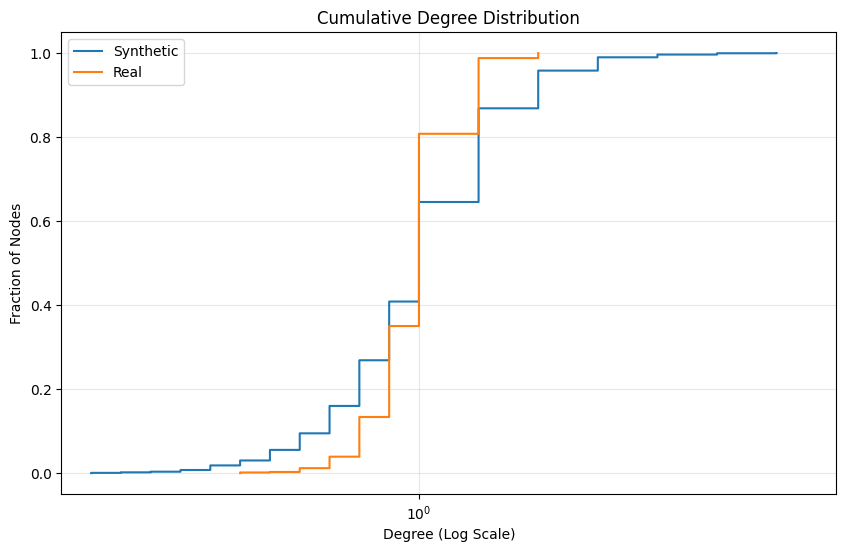

In [88]:
def plot_cdf(gen_deg, real_deg):
    plt.figure(figsize=(10, 6))

    for data, label in zip([gen_deg, real_deg], ['Synthetic', 'Real']):
        # Sort data to create CDF
        x = np.sort(data)
        y = np.arange(1, len(data) + 1) / len(data)
        plt.step(x, y, label=label)

    plt.xscale('log')
    plt.title("Cumulative Degree Distribution")
    plt.xlabel("Degree (Log Scale)")
    plt.ylabel("Fraction of Nodes")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_cdf(gen_degrees, real_degrees)

In [20]:
def edge_density(graph):

    non_zero_edges = graph.nnz

    v = graph.shape[0] #number  nodes

    return non_zero_edges / (v * (v - 1)) * 100




In [152]:
edge_density(real_graph)

4.749312223434081

In [63]:
edge_density(testing)

4.988260157459274

In [58]:
def check_weight_heterogeneity(sparse_matrix):

    weights = sparse_matrix.data

    std = np.std(weights)
    mean = np.mean(weights)

    cv = std / mean


    print(f"Mean Weight: {mean:.6f}")
    print(f"Std Dev: {std:.6f}")
    print(f"Coefficient of Variation (CV): {cv:.4f}")

    return cv

# Usage
print('synthethic')
check_weight_heterogeneity(testing)
print('real')
check_weight_heterogeneity(real_graph)


synthethic
Mean Weight: 0.006230
Std Dev: 0.040571
Coefficient of Variation (CV): 6.5125
real
Mean Weight: 0.006543
Std Dev: 0.047937
Coefficient of Variation (CV): 7.3264


7.326401690426556

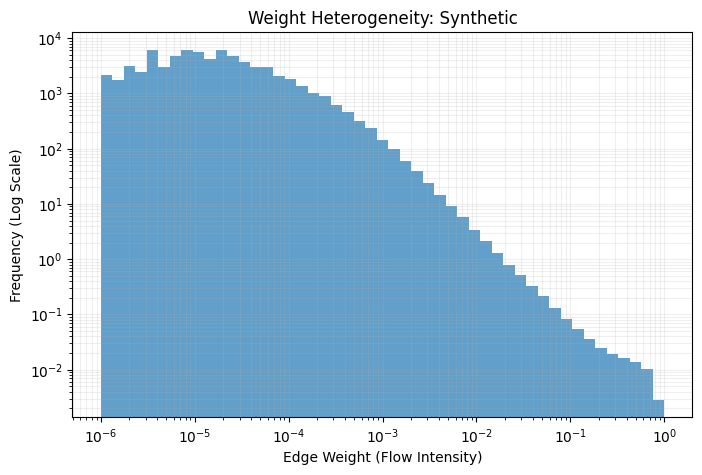

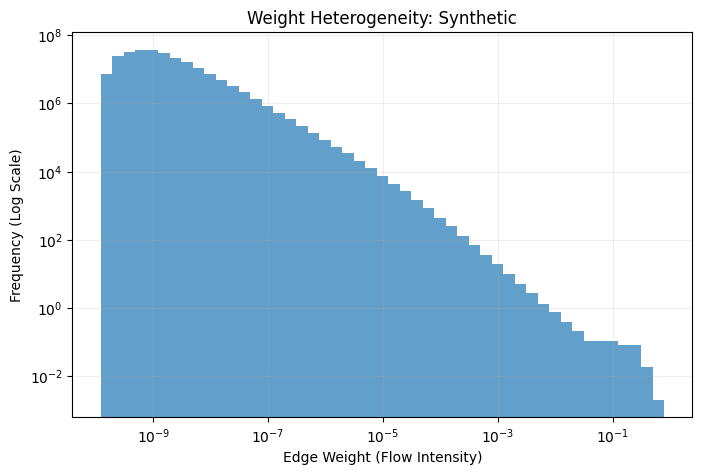

In [64]:
import matplotlib.pyplot as plt

def plot_weight_distribution(sparse_matrix, label="Synthetic"):
    weights = sparse_matrix.data

    plt.figure(figsize=(8, 5))
    # Using log-spaced bins is essential for heterogeneous data
    bins = np.logspace(np.log10(weights.min()), np.log10(weights.max()), 50)
    plt.hist(weights, bins=bins, density=True, alpha=0.7, label=label)

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Edge Weight (Flow Intensity)')
    plt.ylabel('Frequency (Log Scale)')
    plt.title(f'Weight Heterogeneity: {label}')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

plot_weight_distribution(real_graph)
plot_weight_distribution(testing)